# Description of the dataset: Diabetes-MIMIC IV

The dataset used in this study is a subset of the MIMIC-IV (Medical Information Mart for Intensive Care), a large deidentified dataset of patients admitted to Beth  Israel Deaconess Medical Center in Boston between 2008 - 2022. The subset focusses on patients with diabetic diagnoses. The criteria for selecting the subjects were the following:
- Patients diagnosed with diabetes ketoacidosis.
- Subjects aged < 18 years old were excluded.
- Data from each patient’s first ICU admission

These criterias were included tring to replicate the dataset used in the paper "Machine learning prediction models and nomogram to predict the risk ofin-hospital death for severe DKA: A clinical study based on MIMIC-IV, eICUdatabases, and a college hospital ICU" (https://www.sciencedirect.com/science/article/pii/S1386505623000679), with some modifications.

The features included are: 
Demographic: 
- race 
- sex
- age
- weight
- admission emergency 
- insurance

Comorbidities: 
- acute kidney injury
- chronic kidney disease
- diabetes (chronic complication or without)
- cardiac disease
- hypertension
- chronic obstructive pulmonary disease

Laboratory results from the first ICU stay and 24h before and after it, the initial values, the lowest and highest levels of:
- blood PH
- calcium
- creatinine
- hemoglobin
- WBC (white blood cells)
- lactate
- platelets
- potassium
- sodium
- glucose
- chloride
- plasma osmolality (2*sodium + glucose + blood urea nitrogen)
- BUN (blood urea nitrogen)

- Anion gap
- Bicarbonate
- C-Reactive protein -> discarted hight missing values rate
- Albumin -> discarted hight missing values rate

Vital signs in the ICU:
- highest and initial values levels of heart rate
- MAP (mean arterial pressure) -> hight missing values rate
- respiratory rate
- first-day urineoutput

Medicine scores: 
- APS III score
- SOFA score
- GCS score (first gcs total)
- CNS score
- Renal score

Interventions in medicine:
- ventilation
- nitrate pune (nitroprusside ?)
- vasopressor-> (noradrenaline, phenylephrine, epinephrine, dopamine, and dobutamine)
- albumin


## Data Extraction
The dataset was extracted using a SQL query from the *mimiciv_3_1_hosp* dataset, using the following query: 
``` mysql

```


In [5]:
!pip install google-cloud-bigquery
!pip install db-dtypes
!pip install google-cloud-bigquery-storage

In [7]:
import os 
from google.cloud import bigquery
import pandas as pd

In [8]:
SERVICE_ACCOUNT_JSON = "um-thesis-021adda120c0.json"
client = bigquery.Client.from_service_account_json(SERVICE_ACCOUNT_JSON)

In [63]:
query = """
SELECT * 
FROM `um-thesis.cohort_diabetes.icu_dka_dataset`
"""
df = client.query(query).to_dataframe()

## Dataset Structure and Size

The dataset contains 1571 entries, representing laboratory test results for unique patients with diabetic dka diagnosis in their first icu admission. The data includes 85 columns with a mix of categorical and numerical variables.

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1571 entries, 0 to 1570
Data columns (total 85 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   subject_id           1571 non-null   Int64  
 1   race                 1571 non-null   object 
 2   gender               1571 non-null   object 
 3   age                  1571 non-null   Int64  
 4   weight               1542 non-null   float64
 5   admission_type       1571 non-null   object 
 6   insurance            1530 non-null   object 
 7   los                  1571 non-null   float64
 8   aki                  1571 non-null   Int64  
 9   ckd                  1571 non-null   Int64  
 10  diabetes_with_cc     1571 non-null   Int64  
 11  diabetes_without_cc  1571 non-null   Int64  
 12  cardiac_disease      1571 non-null   Int64  
 13  hypertension         1571 non-null   Int64  
 14  copd                 1571 non-null   Int64  
 15  ph_initial           1236 non-null   f

In [65]:
df.describe(include='all')

,subject_id,race,gender,age,weight,admission_type,insurance,los,aki,ckd,...,apsiii,sofa,gcs,cns,renal,ventilation,nitroprusside,vasopressor,albumin,in_hospital_death
count,1571.0,1571,1571,1571.0,1542.000000,1571,1530,1571.000000,1571.0,1571.0,...,1571.0,1571.0,1568.000000,1566.0,1571.0,1571.0,1571.0,1571.0,1571.0,1571.0
unique,<NA>,28,2,<NA>,NaN,8,4,NaN,<NA>,<NA>,...,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
top,<NA>,WHITE,M,<NA>,NaN,EW EMER.,Medicare,NaN,<NA>,<NA>,...,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
freq,<NA>,829,827,<NA>,NaN,1153,562,NaN,<NA>,<NA>,...,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
mean,14839319.288351,NaN,NaN,51.938892,79.243709,NaN,NaN,2.842729,0.49268,0.238065,...,46.13049,3.574793,14.550383,0.49106,1.142584,0.173775,0.001273,0.147677,0.046467,0.052833
std,2890921.002899,NaN,NaN,17.972239,22.383403,NaN,NaN,4.316703,0.500106,0.426035,...,19.419706,3.20131,1.498355,0.857731,1.230209,0.379036,0.035669,0.354892,0.210562,0.22377
min,10002013.0,NaN,NaN,18.0,7.000000,NaN,NaN,0.002269,0.0,0.0,...,11.0,0.0,3.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,12417684.5,NaN,NaN,38.0,64.100000,NaN,NaN,1.038623,0.0,0.0,...,33.0,1.0,15.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,14729536.0,NaN,NaN,53.0,75.000000,NaN,NaN,1.730012,0.0,0.0,...,43.0,3.0,15.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0
75%,17305360.5,NaN,NaN,65.0,90.650000,NaN,NaN,2.827859,1.0,0.0,...,54.0,5.0,15.000000,1.0,2.0,0.0,0.0,0.0,0.0,0.0


In [66]:
df.head()

,subject_id,race,gender,age,weight,admission_type,insurance,los,aki,ckd,...,apsiii,sofa,gcs,cns,renal,ventilation,nitroprusside,vasopressor,albumin,in_hospital_death
0,10002013,OTHER,F,57,96.0,SURGICAL SAME DAY ADMISSION,Medicare,1.314352,0,0,...,29,4,15.0,0,0,1,0,1,1,0
1,10010888,WHITE,M,43,65.4,EW EMER.,Private,9.019225,1,0,...,89,8,12.0,3,2,0,0,0,0,0
2,10015860,WHITE,M,53,88.7,EW EMER.,Private,0.751852,0,0,...,35,1,15.0,0,0,0,0,0,0,0
3,10018862,WHITE,F,57,65.6,URGENT,Medicaid,1.098102,0,0,...,24,5,15.0,0,0,0,0,1,0,0
4,10023239,WHITE,F,29,68.8,EW EMER.,Private,2.825370,0,0,...,42,2,15.0,0,1,0,0,0,0,0


### Missing Values
The missing values of enrolled individuals in MIMIC-IV were all filled with multiple imputations by chained equations (MICE) before the data splitting, separately.



In [48]:
df = pd.read_csv('dataset_test_2.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1571 entries, 0 to 1570
Data columns (total 85 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   subject_id           1571 non-null   int64  
 1   race                 1571 non-null   object 
 2   gender               1571 non-null   object 
 3   age                  1571 non-null   int64  
 4   weight               1542 non-null   float64
 5   admission_type       1571 non-null   object 
 6   insurance            1530 non-null   object 
 7   los                  1571 non-null   float64
 8   aki                  1571 non-null   int64  
 9   ckd                  1571 non-null   int64  
 10  diabetes_with_cc     1571 non-null   int64  
 11  diabetes_without_cc  1571 non-null   int64  
 12  cardiac_disease      1571 non-null   int64  
 13  hypertension         1571 non-null   int64  
 14  copd                 1571 non-null   int64  
 15  ph_initial           1236 non-null   f

In [67]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing 

crp_initial          1486
crp_max              1486
crp_min              1486
albumin_initial       799
albumin_max           799
                     ... 
resp_rate_max           2
heart_rate_max          1
resp_rate_initial       1
mbp_max                 1
mbp_min                 1
Length: 63, dtype: int64

MISSING VALUES 
Before:
- use only the icd-codes
- add data from 24h before and after the icu stay

chloride_initial             13885
chloride_min                 13885
chloride_max                 13885
initial_mbp                  12405
calcium_initial              10064
calcium_max                  10064
calcium_min                  10064
ph_initial                    5918
ph_min                        5918
ph_max                        5918
lactate_min                   5846
lactate_max                   5846
lactate_initial               5846
urineoutput                    875
weight                         468
insurance                      249
wbc_max                        182
platelet_min                   182
platelet_max                   182
platelet_initial               182
hemoglobin_initial             182
wbc_min                        182
wbc_initial                    182
hemoglobin_max                 182
hemoglobin_min                 182
plasma_osmolality_initial      163
plasma_osmolality_min          163
plasma_osmolality_max          163
sodium_max                     160
glucose_max                    160
glucose_min                    160
glucose_initial                160
potassium_initial              160
sodium_min                     160
sodium_initial                 160
potassium_max                  160
potassium_min                  160
bun_initial                    155
bun_min                        155
bun_max                        155
creatinine_max                 153
creatinine_min                 153
creatinine_initial             153
cns                             97
gcs                             89
resp_rate_max                   54
mbp_max                         45
heart_rate_max                  34
renal                           34
initial_resp_rate               23
initial_heart_rate               7
cardiac_disease                  3
ckd                              3
aki                              3
copd                             3
hypertension                     3
dtype: int64

In [2]:
def get_missing_columns(data, missing_percentage=0):
    pc_missing = data.isnull().mean() * 100
    return pc_missing[pc_missing > missing_percentage].sort_values(ascending=False)


In [68]:
pc_missing = get_missing_columns(df, 15)
pc_missing

crp_initial        94.589433
crp_max            94.589433
crp_min            94.589433
albumin_initial    50.859325
albumin_min        50.859325
albumin_max        50.859325
lactate_min        26.352642
lactate_initial    26.352642
lactate_max        26.352642
ph_max             21.323997
ph_initial         21.323997
ph_min             21.323997
dtype: float64

## Missing values:
##### Variables with very high missing rates > 80%
C-Reactive protein: With more than 94% of missing values, deleting it is the best choise.
Initial MBP: Has more than 82% of missing values, but is this needed?

##### Variable with moderate missing rates.
Albumin has more than 50% of missing values, same as in the DKA paper, this is exclude.

##### Variables with Lower missing rates < 30% 
Lactate and PH

*Features after removing missing values: 79*


In [69]:
# Calculate percentage of missing values
pc_missing = df.isnull().mean() * 100

# Identify columns with more than 30% missing values
columns_to_drop = pc_missing[pc_missing > 30].index

# Drop those columns
df = df.drop(columns=columns_to_drop)

# Print results
print(f"Columns dropped: {list(columns_to_drop)}")
print(f"Remaining columns: {list(df.columns)}")
print(f"Number of features: {len(df.columns)}")

# Verify remaining missing percentages
pc_missing_after = df.isnull().mean() * 100
print("\nMissing percentages after dropping:")
print(pc_missing_after[pc_missing_after > 0].sort_values(ascending=False))

Columns dropped: ['crp_initial', 'crp_min', 'crp_max', 'albumin_initial', 'albumin_min', 'albumin_max']
Remaining columns: ['subject_id', 'race', 'gender', 'age', 'weight', 'admission_type', 'insurance', 'los', 'aki', 'ckd', 'diabetes_with_cc', 'diabetes_without_cc', 'cardiac_disease', 'hypertension', 'copd', 'ph_initial', 'ph_min', 'ph_max', 'calcium_initial', 'calcium_min', 'calcium_max', 'creatinine_initial', 'creatinine_min', 'creatinine_max', 'hemoglobin_initial', 'hemoglobin_min', 'hemoglobin_max', 'wbc_initial', 'wbc_min', 'wbc_max', 'lactate_initial', 'lactate_min', 'lactate_max', 'platelet_initial', 'platelet_min', 'platelet_max', 'potassium_initial', 'potassium_min', 'potassium_max', 'sodium_initial', 'sodium_min', 'sodium_max', 'glucose_initial', 'glucose_min', 'glucose_max', 'chloride_initial', 'chloride_min', 'chloride_max', 'bun_initial', 'bun_min', 'bun_max', 'osmolality_initial', 'osmolality_min', 'osmolality_max', 'anion_gap_initial', 'anion_gap_min', 'anion_gap_max', 

#### Clean dataset

Admision type removed -> but emergency flag added

In [70]:
emergency_types = [
    'AMBULATORY OBSERVATION', 'DIRECT EMER.', 'URGENT', 'EW EMER.',
    'DIRECT OBSERVATION', 'EU OBSERVATION', 'OBSERVATION ADMIT'
]

df['emergency'] = df['admission_type'].isin(emergency_types).astype(int)

In [71]:
df['emergency'].unique()

array([0, 1])

In [72]:
# Remove unwanted features
drop_columns = ["admission_type"]
df= df.drop(columns=drop_columns)

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1571 entries, 0 to 1570
Data columns (total 79 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   subject_id           1571 non-null   Int64  
 1   race                 1571 non-null   object 
 2   gender               1571 non-null   object 
 3   age                  1571 non-null   Int64  
 4   weight               1542 non-null   float64
 5   insurance            1530 non-null   object 
 6   los                  1571 non-null   float64
 7   aki                  1571 non-null   Int64  
 8   ckd                  1571 non-null   Int64  
 9   diabetes_with_cc     1571 non-null   Int64  
 10  diabetes_without_cc  1571 non-null   Int64  
 11  cardiac_disease      1571 non-null   Int64  
 12  hypertension         1571 non-null   Int64  
 13  copd                 1571 non-null   Int64  
 14  ph_initial           1236 non-null   float64
 15  ph_min               1236 non-null   f

#### Save dataset into csv

In [74]:
from datetime import datetime

today_str = datetime.today().strftime('%Y%m%d')
df.to_csv(f'icu_dka_dataset_{today_str}.csv', index=False)

## Plots and graphs

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")

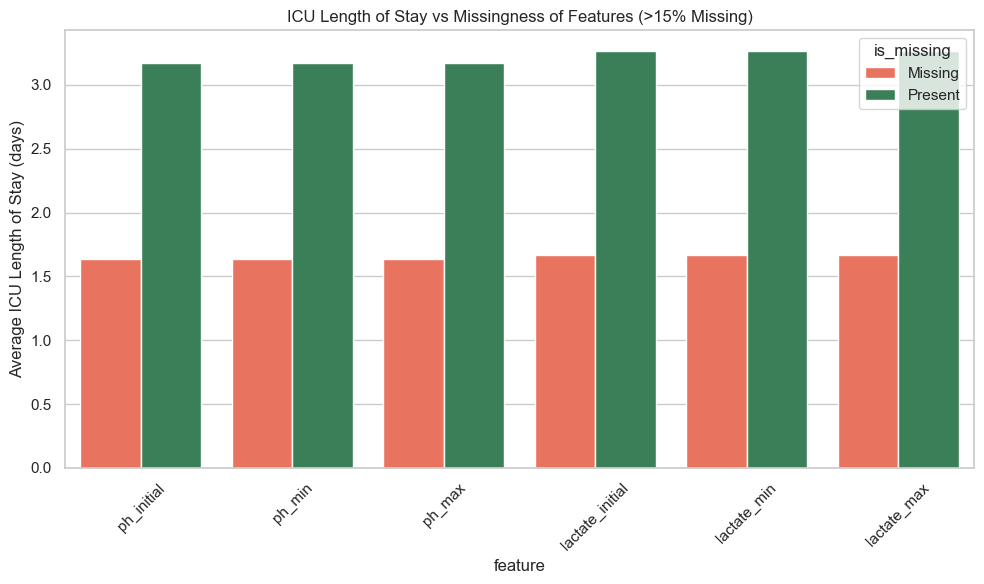

In [75]:
def create_missingness_summary(df):
    los_summary = []
    missing_percent = df.isna().mean()

    for column in df.columns:
        if column != 'los' and missing_percent[column] > 0.15:
            avg_los_missing = df[df[column].isna()]['los'].mean()
            avg_los_present = df[df[column].notna()]['los'].mean()
            
            los_summary.append({
                'feature': column,
                'avg_los': avg_los_missing,
                'is_missing': 'Missing'
            })
            los_summary.append({
                'feature': column,
                'avg_los': avg_los_present,
                'is_missing': 'Present'
            })
    
    return pd.DataFrame(los_summary)

df_los_summary = create_missingness_summary(df)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_los_summary,
    x="feature",
    y="avg_los",
    hue="is_missing",
    palette={"Missing": "tomato", "Present": "seagreen"}
)
plt.xticks(rotation=45)
plt.ylabel("Average ICU Length of Stay (days)")
plt.title("ICU Length of Stay vs Missingness of Features (>15% Missing)")
plt.tight_layout()
plt.show()

In [76]:
categorical_vars = ['gender', 'race', 'insurance']
for col in categorical_vars:
    if col in df.columns:
        print(f"\n{col}:\n", df[col].value_counts(dropna=False))


gender:
 gender
M    827
F    744
Name: count, dtype: int64

race:
 race
WHITE                                        829
BLACK/AFRICAN AMERICAN                       344
UNKNOWN                                       81
OTHER                                         59
WHITE - OTHER EUROPEAN                        39
HISPANIC/LATINO - PUERTO RICAN                32
HISPANIC OR LATINO                            28
UNABLE TO OBTAIN                              21
BLACK/CARIBBEAN ISLAND                        18
ASIAN - CHINESE                               17
ASIAN                                         14
BLACK/CAPE VERDEAN                            13
HISPANIC/LATINO - DOMINICAN                   12
BLACK/AFRICAN                                 12
WHITE - RUSSIAN                                8
PORTUGUESE                                     6
HISPANIC/LATINO - SALVADORAN                   5
HISPANIC/LATINO - CENTRAL AMERICAN             5
ASIAN - SOUTH EAST ASIAN                    

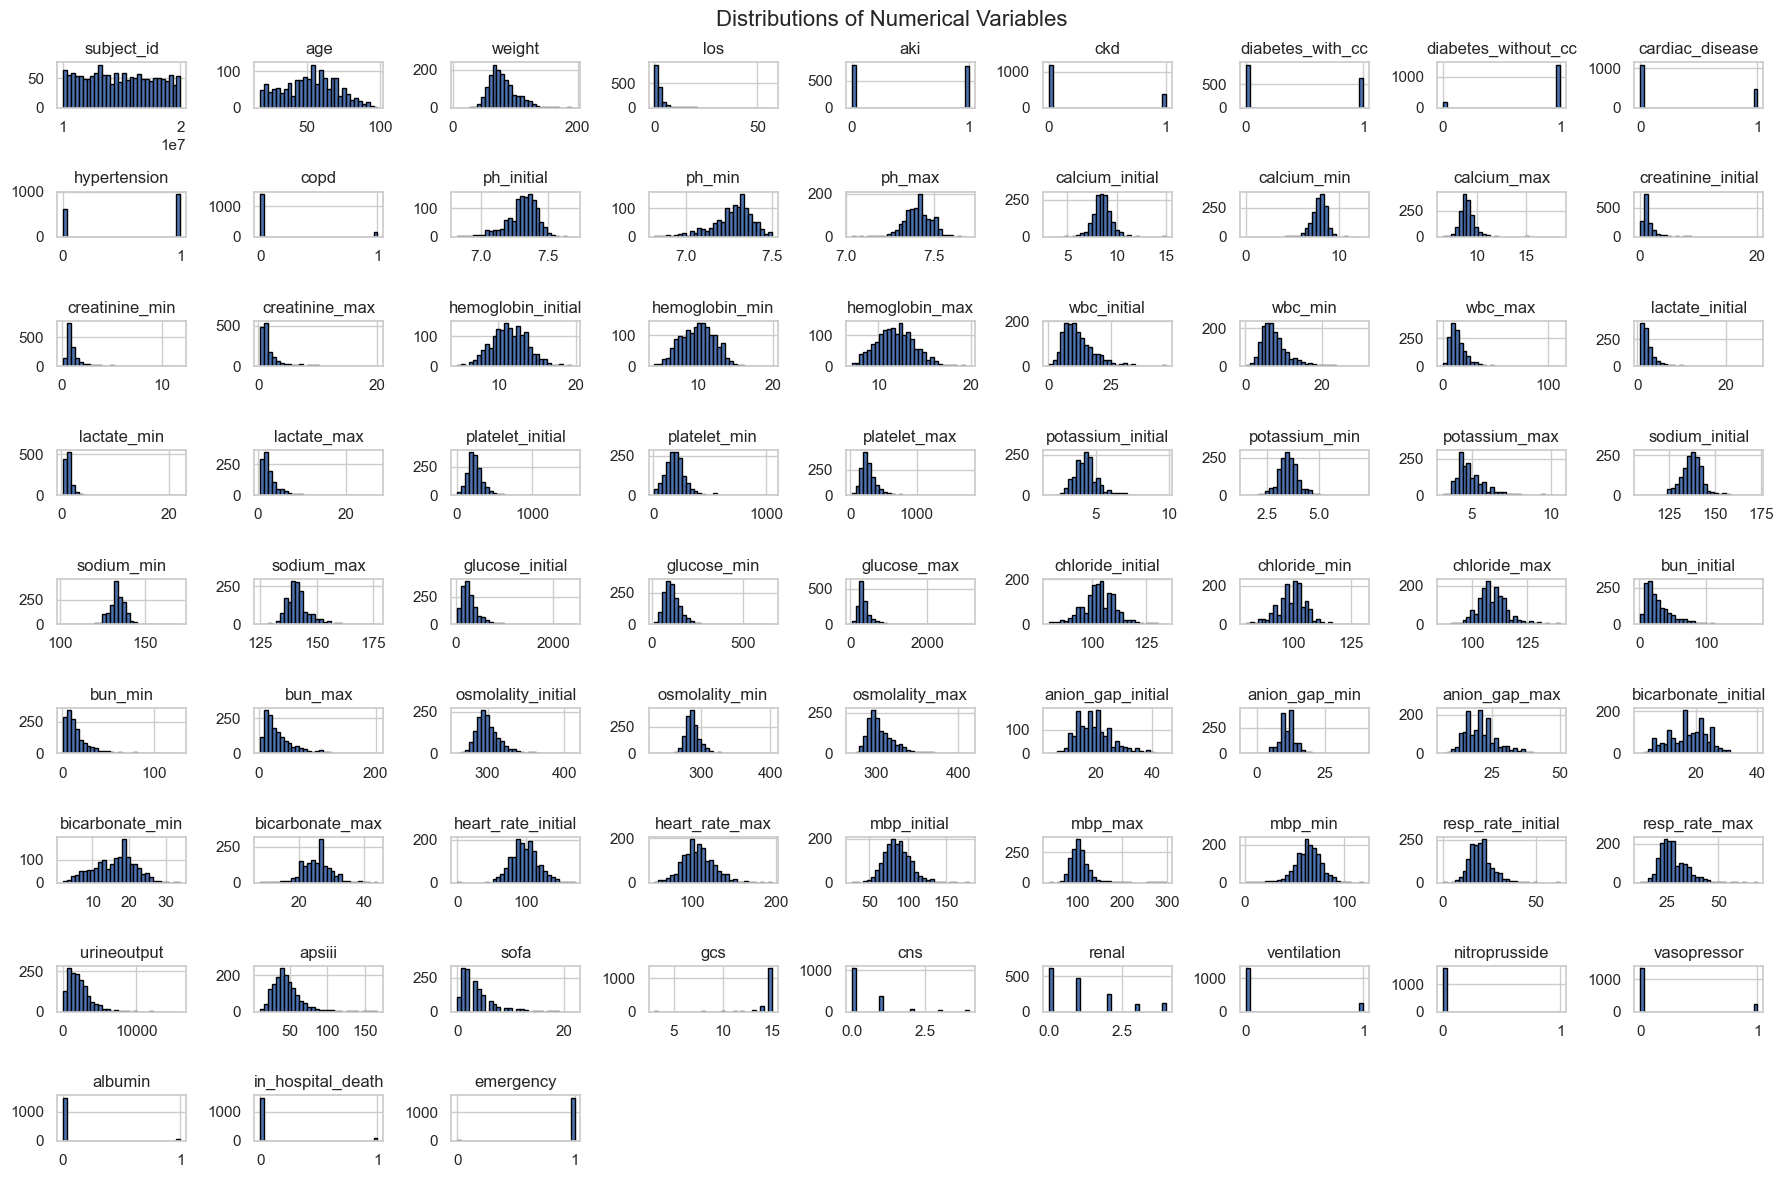

In [77]:
import matplotlib.pyplot as plt
# Histograms for numerical features
numeric_vars = df.select_dtypes(include='number').columns.tolist()
df[numeric_vars].hist(figsize=(18, 12), bins=30, edgecolor='black')
plt.suptitle("Distributions of Numerical Variables", fontsize=16)
plt.tight_layout()
plt.show()

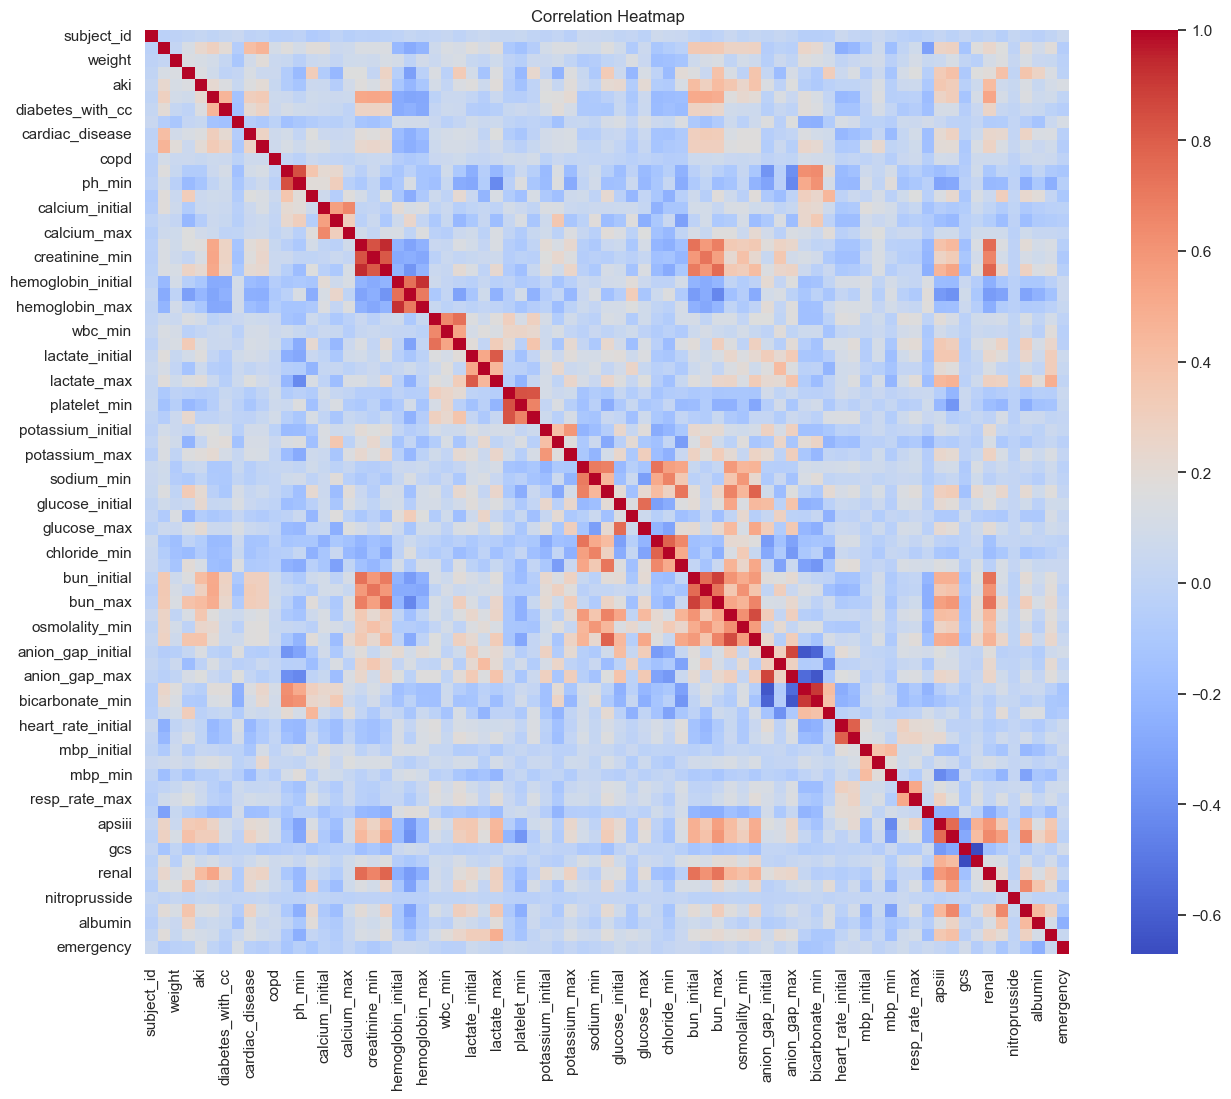

in_hospital_death    1.000000
lactate_max          0.485479
sofa                 0.399484
apsiii               0.348283
lactate_min          0.314784
lactate_initial      0.313145
vasopressor          0.286675
renal                0.266466
wbc_max              0.243354
osmolality_max       0.240936
Name: in_hospital_death, dtype: float64


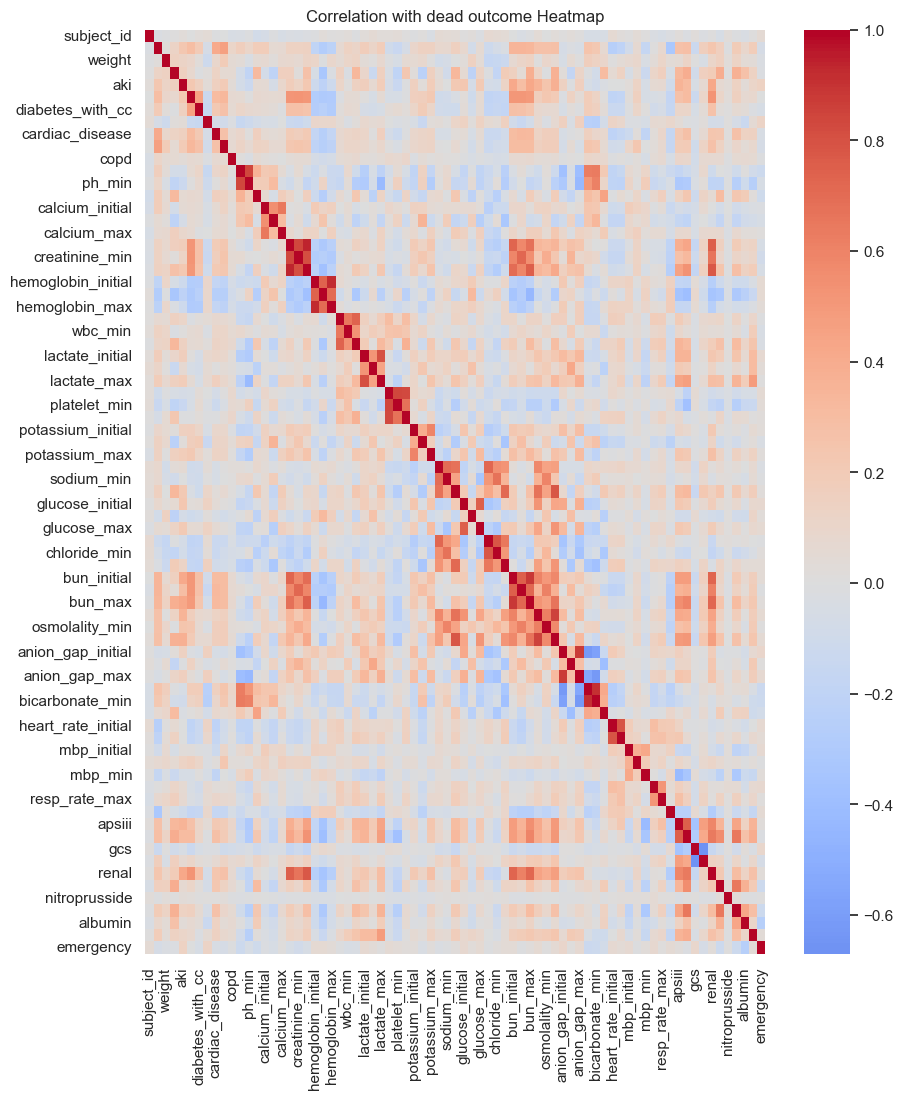

In [78]:
plt.figure(figsize=(16, 12))
sns.heatmap(df[numeric_vars].corr(), cmap='coolwarm', annot=False, fmt=".2f", square=True)
plt.title("Correlation Heatmap")
plt.show()

correlation = df.corr(numeric_only=True)['in_hospital_death'].sort_values(ascending=False)
print(correlation.head(10))
# 
plt.figure(figsize=(10, 12))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Correlation with dead outcome Heatmap')
plt.show()


## Exploratory Data Analysis


In [31]:
import numpy as np

### Distribution of age

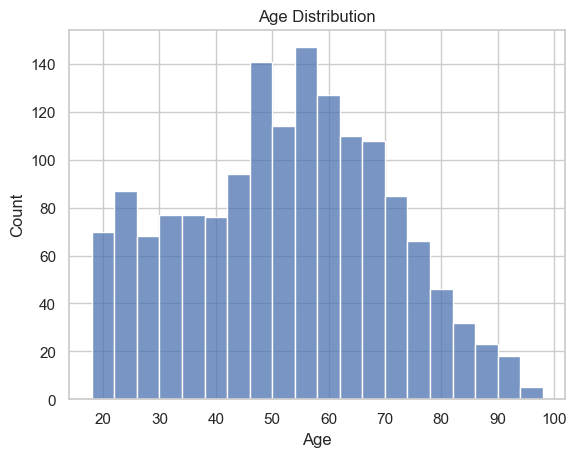

In [79]:
# sns.histplot(df.drop_duplicates(subset="subject_id")['age'].dropna().astype(int), bins=20)
sns.histplot(df['age'].dropna().astype(int).to_numpy(), bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

### Gender balance

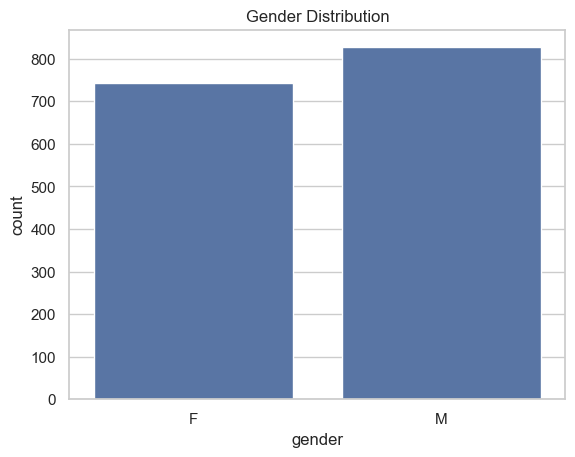

In [80]:
sns.countplot(data=df, x='gender')
plt.title("Gender Distribution")
plt.show()


### Distribution of the weight

Outlier the weight?

Maximum weight after filtering (<= 200): 195.0
Number of weights above 250: 0
Values above 200: []


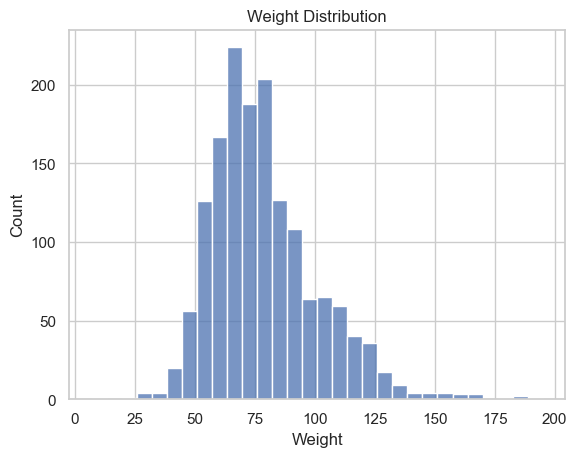

<Figure size 640x480 with 0 Axes>

In [81]:
weights = df['weight'].replace([np.inf, -np.inf], np.nan).dropna()

weights_less_200 = weights[weights <= 200].to_numpy()
weights_more_200 = weights[weights > 200].to_numpy()

max_weight = weights_less_200.max() if len(weights_less_200) > 0 else np.nan
print(f"Maximum weight after filtering (<= 200): {max_weight}")
print(f"Number of weights above 250: {(weights > 250).sum()}")
print(f"Values above 200: {weights_more_200}")

sns.histplot(df['weight'].dropna().astype(int).to_numpy(), bins=30)
plt.title("Weight Distribution")
plt.xlabel("Weight")
plt.show()

# sns.histplot(weights.to_numpy(), bins=100, ax=axs[0])
# axs[0].set_title("Weight Distribution (All Cleaned Values)")
# axs[0].set_xlabel("Weight")

# fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# sns.histplot(weights.to_numpy(), bins=100, ax=axs[0])
# axs[0].set_title("Weight Distribution (All Cleaned Values)")
# axs[0].set_xlabel("Weight")

# sns.histplot(weights_less_200, bins=10, ax=axs[1])
# axs[1].set_title("Weight Distribution (≤ 200)")
# axs[1].set_xlabel("Weight")

# sns.histplot(weights_more_200, bins=10, ax=axs[2])
# axs[2].set_title("Weight Distribution (> 200)")
# axs[2].set_xlabel("Weight")

plt.tight_layout()
plt.show()

### Insurance

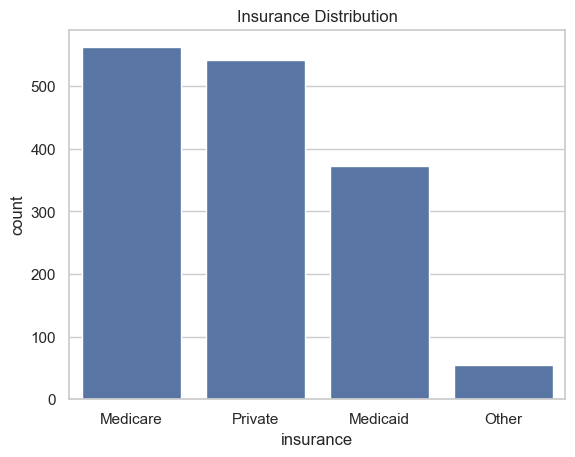

In [82]:
sns.countplot(data=df, x='insurance')
plt.title("Insurance Distribution")
plt.show()

### Emegency


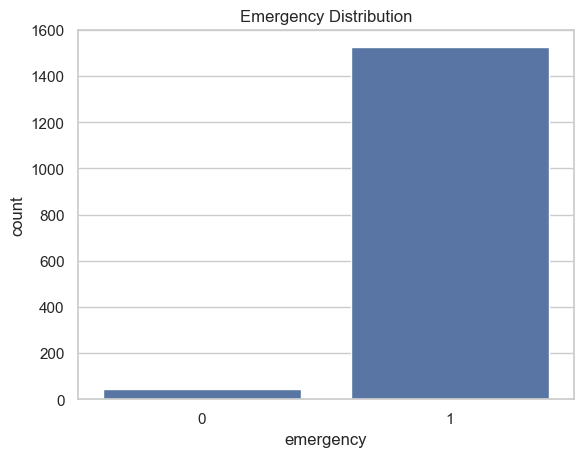

In [83]:
sns.countplot(data=df, x='emergency')
plt.title("Emergency Distribution")
plt.show()

### Deads
 In hspital death

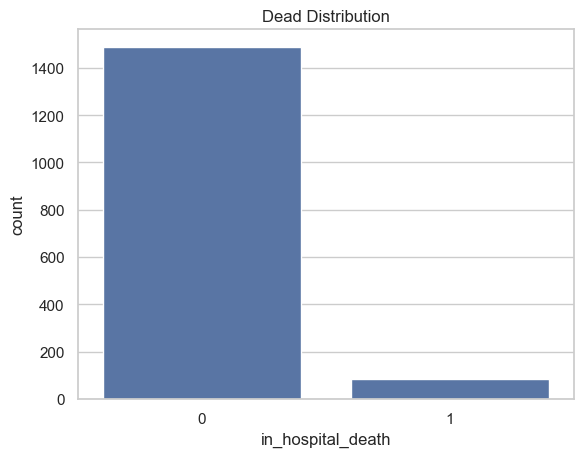

In [84]:
sns.countplot(data=df, x='in_hospital_death')
plt.title("Dead Distribution")
plt.show()

### Laboratory test

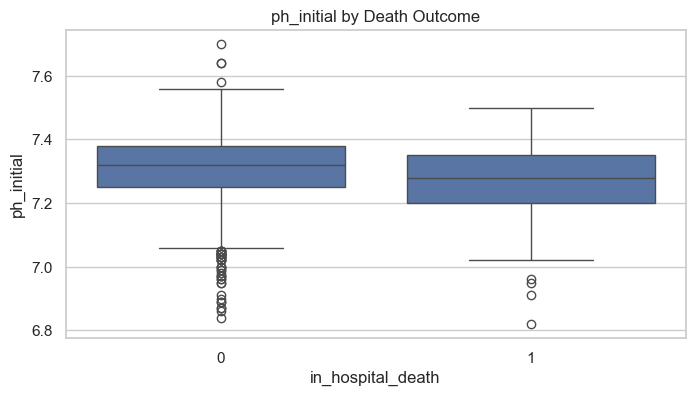

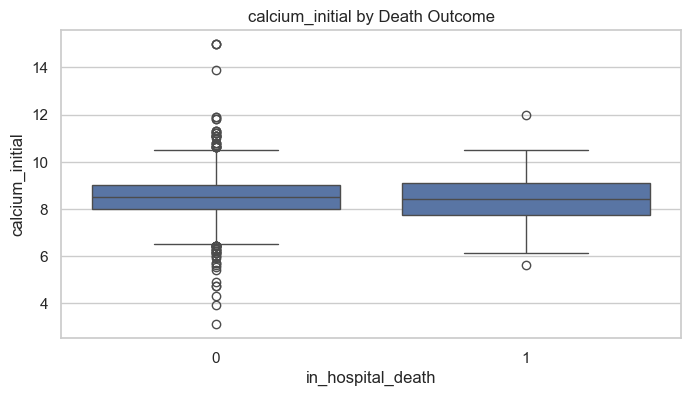

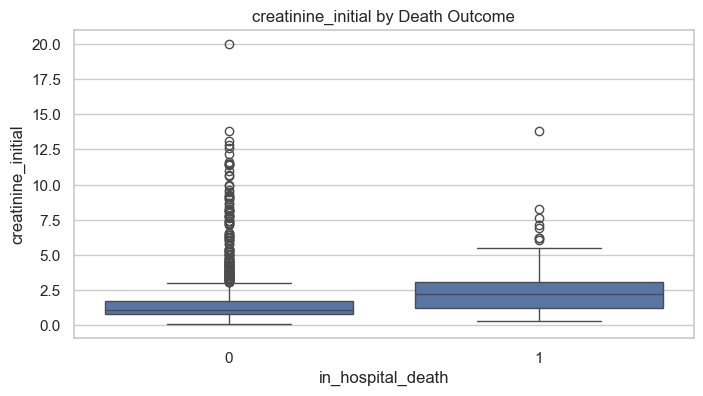

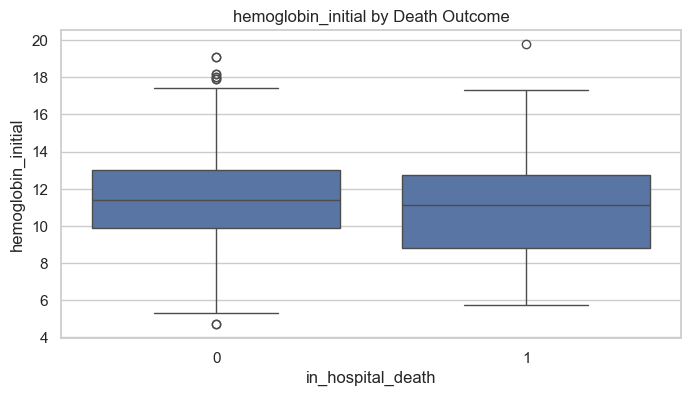

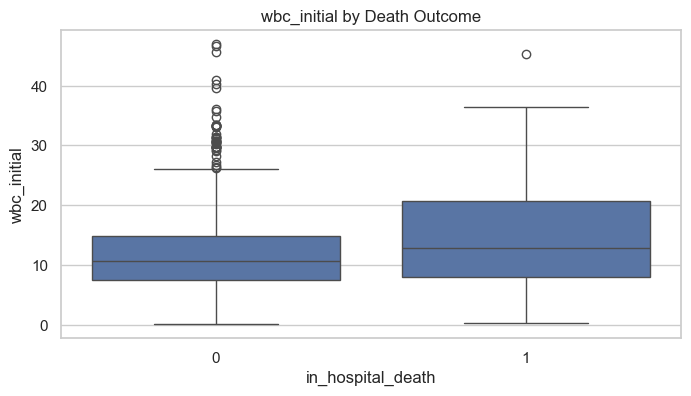

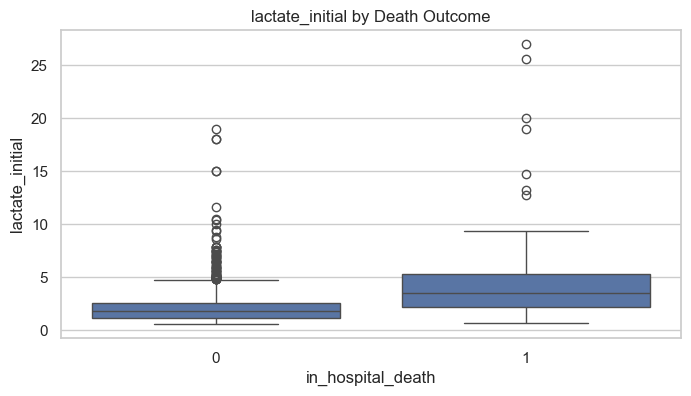

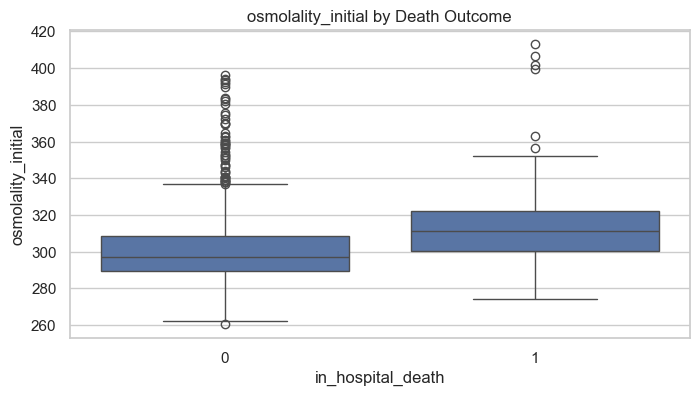

In [85]:
lab_features = [
    'ph_initial', 'calcium_initial', 'creatinine_initial',
    'hemoglobin_initial', 'wbc_initial', 'lactate_initial', 'osmolality_initial'
]

for feature in lab_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x='in_hospital_death', y=feature)
    plt.title(f'{feature} by Death Outcome')
    plt.show()




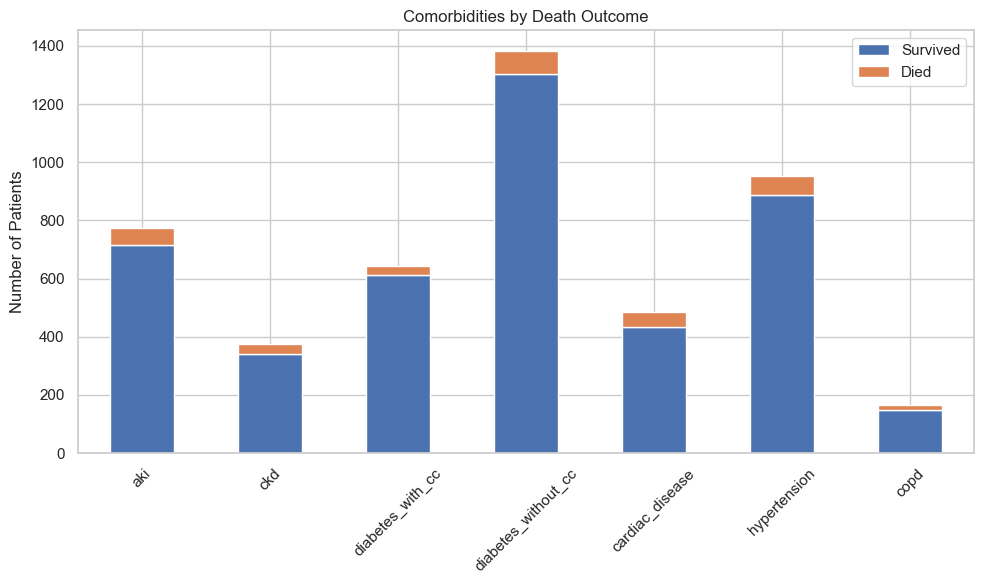

In [86]:
comorbidities = [
    'aki', 'ckd', 'diabetes_with_cc',
    'diabetes_without_cc', 'cardiac_disease', 'hypertension', 'copd'
]

comorbidity_counts = df.groupby('in_hospital_death')[comorbidities].sum().T
comorbidity_counts.columns = ['Survived', 'Died']
comorbidity_counts.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Comorbidities by Death Outcome')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Characteristic at baseline between survivors and non-survivors group

In [3]:
!pip install tableone
!pip install --upgrade statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 194.3 MB/s eta 0:00:00
  Attempting uninstall: patsy
    Found existing installation: patsy 0.5.3
    Uninstalling patsy-0.5.3:
      Successfully uninstalled patsy-0.5.3
  Attempting uninstall: jinja2
    Found existing installation: Jinja2 3.1.2
    Uninstalling Jinja2-3.1.2:
      Successfully uninstalled Jinja2-3.1.2
  Attempting uninstall: statsmodels
    Found existing installation: statsmodels 0.14.0
    Uninstalling statsmodels-0.14.0:
      Successfully uninstalled statsmodels-0.14.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jupyterlab-lsp 5.1.0 requires jupyterlab<5.0.0a0,>=4.1.0, but you have jupyterlab 3.6.8 which is incompatible.

[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.

In [1]:
import sys
!{sys.executable} -m pip install scipy
!pip install pandas==2.1.4


[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 82.5 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.0.2
    Uninstalling pandas-2.0.2:
      Successfully uninstalled pandas-2.0.2

[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [57]:
import pandas as pd
import numpy as np
from scipy.stats import normaltest, kurtosistest
from tableone import TableOne

In [89]:
def get_nonnormal_columns(df, alpha=0.05):
    # Agostino and Anscombe tests
    # D’Agostino and Pearson Normality Test
    non_normal_cols = []
    for col in df.columns:
        data = df[col].dropna()
        if len(data) < 8:
            continue

        stat_nt, p_nt = normaltest(data)
        stat_kg, p_kg = kurtosistest(data)
        if p_nt < alpha or p_kg < alpha:
            non_normal_cols.append(col)
    return non_normal_cols

In [87]:
# Load your dataset
data = pd.read_csv('icu_dka_dataset_20250723.csv')

# Define labels and columns
column_labels = {
    'age': 'Age (year)',
    'gender': 'Male (%)',
    'race': 'White (%)',
    'heart_rate_initial': 'Heartrate (bpm)',
    'heart_rate_max': 'Heartrate_max (bpm)',
    'mbp_initial': 'MAP (mmHg)',
    'mbp_min': 'MAP_min (mmHg)',
    'resp_rate_initial': 'Respiratory_rate (insp/min)',
    'resp_rate_max': 'Respiratoryrate_max (insp/min)',
    'urineoutput': 'Urineoutput (ml)',
    'apsiii': 'APS III score',
    'sofa': 'SOFA score',
    'gcs': 'GCS score',
    'cns': 'CNS score',
    'renal': 'Renal score',
    'weight': 'Weight (kg)',
    'emergency': 'Admission, emergency (%)',
    'ventilation': 'Ventilation (%)',
    'nitroprusside': 'Nitrate pune (%)',
    'vasopressor': 'Vasopressor (%)',
    'albumin': 'Albumin (%)',
    'aki': 'AKI (%)',
    'ckd': 'CKD (%)',
    'cardiac_disease': 'Cardiac disease (%)',
    'hypertension': 'Hypertension (%)',
    'copd': 'COPD (%)',
    'lactate_max': 'Lactate_max (mmol/L)',
    'creatinine_initial': 'Scr (mg/dL)',
    'creatinine_max': 'Scr_max (mg/dL)',
    'ph_initial': 'PH',
    'ph_min': 'PH_min',
    'glucose_initial': 'Glucose (mg/dL)',
    'glucose_max': 'Glucose_max (mg/dL)',
    'sodium_initial': 'Sodium (mEq/L)',
    'sodium_max': 'Sodium_max (mEq/L)',
    'potassium_initial': 'Potassium (mEq/L)',
    'potassium_max': 'Potassium_max (mEq/L)',
    'calcium_initial': 'Calcium (mg/dL)',
    'chloride_initial': 'Chloride (mEq/L)',
    'wbc_initial': 'WBC (K/uL)',
    'wbc_max': 'WBC_max (K/uL)',
    'platelet_initial': 'PLT (K/uL)',
    'platelet_min': 'PLT_min (K/uL)',
    'bun_max': 'BUN_max (mg/dL)',
    'osmolality_initial': 'osmolarity',
    'osmolality_max': 'osmolarity_max',
    'osmolality_min': 'osmolarity_min'
}

columns = list(column_labels.keys())

categorical = [
    'gender', 'race', 'emergency', 'ventilation', 'nitroprusside', 'vasopressor',
    'albumin', 'aki', 'ckd', 'cardiac_disease', 'hypertension', 'copd'
]
continuous = [col for col in columns if col not in categorical]


labels = {var: {1: column_labels[var]} for var in categorical}
# print(labels)

# Custom labels
survivors_n = len(data[data['in_hospital_death'] == 0])
nonsurvivors_n = len(data[data['in_hospital_death'] == 1])
data['in_hospital_death_label'] = data['in_hospital_death'].map({
    1: f'Nonsurvivors (n={nonsurvivors_n})',
    0: f'Survivors (n={survivors_n})'
})

limit={
    'gender':1,
    'race':1
}

nonnormal = get_nonnormal_columns(data[continuous])
# Remove age to simulate the paper table
nonnormal.remove('age')

# Create TableOne
table = TableOne(
    data,
    columns=columns,
    categorical=categorical,
    labels=labels,
    groupby='in_hospital_death_label',
    pval=True,
    rename=column_labels,
    label_suffix=False,
    missing=False,
    limit=limit,
    decimals=2,
    nonnormal=nonnormal
)

# Print TableOne
print(table.tabulate(tablefmt="github"))


|                                |       | Overall                   | Nonsurvivors (n=83)     | Survivors (n=1488)        | P-Value   |
|--------------------------------|-------|---------------------------|-------------------------|---------------------------|-----------|
| n                              |       | 1571                      | 83                      | 1488                      |           |
| Age (year)                     |       | 51.94 (17.97)             | 65.59 (15.56)           | 51.18 (17.80)             | <0.001    |
| Male (%)                       | M     | 827 (52.64)               | 44 (53.01)              | 783 (52.62)               | 1.000     |
| White (%)                      | WHITE | 829 (52.77)               | 30 (36.14)              | 799 (53.70)               | <0.001    |
| Heartrate (bpm)                |       | 97.00 [85.00,109.00]      | 95.00 [81.50,108.50]    | 97.00 [85.00,109.00]      | 0.602     |
| Heartrate_max (bpm)            |       

In [62]:
table.to_csv('table.csv')

## MICE Imputation
ph_* and lactate_* > 28% of missing values; urineoutput and calcium_* ~ 4%; weight ~ 2%; insurance ~1%; hemoglobin_*, platelet_*, wbc_*, osmolality_*, glucose_*, chloride_*, potassium_*, sodium_*, bun_*, creatinine_*, cns, gcs, resp_rate_max, mbp_max, renal, heart_rate_max, initial_mbp, initial_resp_rate, initial_heart_rate, cardiac_disease, ckd, aki, copd, hypertension < 1%

Features to impute with MICE:
ph, lactate, urineoutput, calcium, weight, hemoglobin, platelet, wbc, osmolality, glucose, chloride, potassium, sodium, bun, creatinine, cns, gcs, resp_rate_max, mbp_max, renal, heart_rate_max, initial_mbp, initial_resp_rate, initial_heart_rate, cardiac_disease, ckd, aki, copd, hypertension.
Not MICE:
Insurance